In [10]:
import pandas as pd
import numpy as np
import blinksear as ear
import blinksdistance as distance
import blinkscolors as colors
import json
import matplotlib.pyplot as plt
from pathlib import Path

from blinksear import isBlinkByEar
from blinksdistance import BlinkDistance
from blinkscolors import Colors
from blinkscorrelation import Correlation

In [11]:
def generate_webgazer_dataframe(df):
    df_webgazer = df[~df["webgazer_data"].isna()]
    dfs = []
    for row in range(len(df_webgazer)):
        data_list = json.loads(df_webgazer["webgazer_data"].iloc[row])
        df_tmp = pd.DataFrame(data_list)
        df_tmp["trial"] = row + 1
        dfs.append(df_tmp)
    return pd.concat(dfs)

In [12]:
# This can load all data but is not storing df_webgazer in any place
files = Path("./data").glob("*.csv")
dfs = []
i = 0
for file in files:
    if "blink" in str(file):
        print(file)
        df = pd.read_csv(file)
        df_tmp = generate_webgazer_dataframe(df)
        print(len(df_tmp))
        df_tmp["experiment"] = i
        df_tmp["file_name"] = str(file)
        i+=1
        dfs.append(df_tmp)

df_webgazer = pd.concat(dfs)
print(len(df_webgazer))

data/blink-experiment-9.csv
2296
data/blink-experiment-15.csv
1986
data/blink-experiment-8.csv
1589
data/blink-experiment-12.csv
1900
data/blink-experiment-13.csv
1383
data/blink-experiment-11.csv
1407
data/blink-experiment-10.csv
1135
data/blink-experiment-6.csv
1432
data/blink-experiment-7.csv
1923
data/blink-experiment-5.csv
1272
16323


In [13]:
blinkDistance = distance.BlinkDistance()
blinkColors = Colors()
blinkCorrelations = Correlation()


df_webgazer["isBlinkByEar"] = df_webgazer["importantKeypoints"].map(
    lambda x: isBlinkByEar(
        x["rightEyeTopArc"],
        x["rightEyeBottomArc"],
        x["leftEyeTopArc"],
        x["leftEyeBottomArc"],
    )
)
df_webgazer["isBlinkByDistance"] = df_webgazer["importantKeypoints"].map(
    lambda x: blinkDistance.isBlinkByDistance(
        x["rightEyeTopArc"],
        x["rightEyeBottomArc"],
        x["leftEyeTopArc"],
        x["leftEyeBottomArc"],
    )
)
df_webgazer["isBlinkColors"] = df_webgazer.apply(
    lambda row: blinkColors.isBlinkByColors(
        list(row["leftEye"]["data"].values()), list(row["rightEye"]["data"].values())
    ),
    axis=1,
)


df_webgazer["isBlinkByCorrelation"] = df_webgazer.apply(
    lambda row: blinkCorrelations.isBlinkByCorrelation(
        list(row["leftEye"]["data"].values()), list(row["rightEye"]["data"].values())
    ),
    axis=1,
)


# df_webgazer['isBlinkByEar'] = df_webgazer['importantKeypoints'].map(lambda x: isBlinkByEar(x['rightEyeTopArc'], x['rightEyeBottomArc'], x['leftEyeTopArc'], x['leftEyeBottomArc']))

df_webgazer

,x,y,t,importantKeypoints,leftEye,rightEye,dz,trial,experiment,file_name,isBlinkByEar,isBlinkByDistance,isBlinkColors,isBlinkByCorrelation
0,0,0,62,"{'noseX': 288.29, 'noseY': 313.05, 'topY': 190...","{'data': {'0': 84, '1': 62, '2': 42, '3': 255,...","{'data': {'0': 144, '1': 105, '2': 82, '3': 25...",51.57,1,0,data/blink-experiment-9.csv,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False]","[False, False, False, False, False, False]","[False, False, False, False, False, False]"
1,0,0,81,"{'noseX': 289.14, 'noseY': 313.56, 'topY': 190...","{'data': {'0': 44, '1': 30, '2': 15, '3': 255,...","{'data': {'0': 66, '1': 41, '2': 27, '3': 255,...",52.57,1,0,data/blink-experiment-9.csv,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False]","[False, False, False, False, False, False]","[False, False, False, False, False, False]"
2,0,0,106,"{'noseX': 289.29, 'noseY': 313.86, 'topY': 190...","{'data': {'0': 46, '1': 31, '2': 15, '3': 255,...","{'data': {'0': 66, '1': 43, '2': 26, '3': 255,...",53.01,1,0,data/blink-experiment-9.csv,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False]","[False, False, False, False, False, False]","[False, False, False, False, False, False]"
3,0,0,142,"{'noseX': 288.98, 'noseY': 313.11, 'topY': 190...","{'data': {'0': 46, '1': 31, '2': 15, '3': 255,...","{'data': {'0': 64, '1': 42, '2': 25, '3': 255,...",50.86,1,0,data/blink-experiment-9.csv,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False]","[False, False, False, False, False, False]","[False, False, False, False, False, False]"
4,0,0,175,"{'noseX': 289.17, 'noseY': 313.61, 'topY': 190...","{'data': {'0': 48, '1': 32, '2': 16, '3': 255,...","{'data': {'0': 67, '1': 42, '2': 27, '3': 255,...",52.18,1,0,data/blink-experiment-9.csv,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False]","[False, False, False, False, False, False]","[False, False, False, False, False, False]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
223,0,0,7584,"{'noseX': 361.32, 'noseY': 259.74, 'topY': 173...","{'data': {'0': 60, '1': 46, '2': 34, '3': 255,...","{'data': {'0': 69, '1': 53, '2': 36, '3': 255,...",66.11,6,9,data/blink-experiment-5.csv,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, True]","[False, False, False, False, False, False]","[False, False, False, False, False, False]"
224,0,0,7622,"{'noseX': 361.16, 'noseY': 259.39, 'topY': 173...","{'data': {'0': 60, '1': 47, '2': 32, '3': 255,...","{'data': {'0': 70, '1': 52, '2': 36, '3': 255,...",65.16,6,9,data/blink-experiment-5.csv,"[False, False, False, False, False, False, Tru...","[False, False, False, False, False, True]","[False, False, False, False, False, False]","[False, False, False, False, False, False]"
225,0,0,7653,"{'noseX': 361.02, 'noseY': 259.52, 'topY': 173...","{'data': {'0': 60, '1': 47, '2': 30, '3': 255,...","{'data': {'0': 67, '1': 52, '2': 35, '3': 255,...",66.11,6,9,data/blink-experiment-5.csv,"[False, False, False, False, False, False, Tru...","[False, False, False, False, False, True]","[False, False, False, False, False, False]","[False, False, False, False, False, False]"
226,0,0,7687,"{'noseX': 361.42, 'noseY': 259.34, 'topY': 173...","{'data': {'0': 60, '1': 44, '2': 34, '3': 255,...","{'data': {'0': 66, '1': 51, '2': 33, '3': 255,...",64.75,6,9,data/blink-experiment-5.csv,"[False, False, False, False, False, False, Tru...","[False, False, False, False, False, True]","[False, False, False, False, False, False]","[False, False, False, False, False, False]"


In [ ]:
df_webgazer["Blink_sample"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[0]==True))
df_webgazer["Blink_sample1"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[1]==True)+1)
df_webgazer["Blink_sample2"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[2]==True)+2)
df_webgazer["Blink_sample3"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[3]==True)+3)
df_webgazer["Blink_sample4"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[4]==True)+4)
df_webgazer["Blink_sample5"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[5]==True)+5)
df_webgazer["Blink_sample6"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[6]==True)+6)
df_webgazer["Blink_sample7"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[7]==True)+7)

In [14]:
df_webgazer["Blink_sample"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[0]==True))
df_webgazer["Blink_sample1"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[1]==True))
df_webgazer["Blink_sample2"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[2]==True))
df_webgazer["Blink_sample3"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[3]==True))
df_webgazer["Blink_sample4"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[4]==True))
df_webgazer["Blink_sample5"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[5]==True))
df_webgazer["Blink_sample6"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[6]==True))
df_webgazer["Blink_sample7"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[7]==True))

In [ ]:
df_webgazer.head()

In [ ]:
df_webgazer['Blink_sample3'][df_webgazer['Blink_sample3'].diff()>0].shape

In [15]:
df_webgazer["Blink_sample0_diff"] = (df_webgazer['Blink_sample'].shift(1)+1 == df_webgazer['Blink_sample'])
df_webgazer["Blink_sample1_diff"] = (df_webgazer['Blink_sample1'].shift(1)+1 == df_webgazer['Blink_sample1'])
df_webgazer["Blink_sample2_diff"] = (df_webgazer['Blink_sample2'].shift(1)+1 == df_webgazer['Blink_sample2'])
df_webgazer["Blink_sample3_diff"] = (df_webgazer['Blink_sample3'].shift(1)+1 == df_webgazer['Blink_sample3'])
df_webgazer["Blink_sample4_diff"] = (df_webgazer['Blink_sample4'].shift(1)+1 == df_webgazer['Blink_sample4'])
df_webgazer["Blink_sample5_diff"] = (df_webgazer['Blink_sample5'].shift(1)+1 == df_webgazer['Blink_sample5'])
df_webgazer["Blink_sample6_diff"] = (df_webgazer['Blink_sample6'].shift(1)+1 == df_webgazer['Blink_sample6'])
df_webgazer["Blink_sample7_diff"] = (df_webgazer['Blink_sample7'].shift(1)+1 == df_webgazer['Blink_sample7'])

results = []
for x in range(0,8):
    tmp_result = df_webgazer.groupby('trial')['Blink_sample' + str(x) + '_diff'].sum().reset_index()
    #tmp_result['sample'] = x
    results.append(tmp_result)

result = pd.concat(results, axis=1, join='inner')
result

,trial,Blink_sample0_diff,trial,Blink_sample1_diff,trial,Blink_sample2_diff,trial,Blink_sample3_diff,trial,Blink_sample4_diff,trial,Blink_sample5_diff,trial,Blink_sample6_diff,trial,Blink_sample7_diff
0,1,116,1,109,1,86,1,79,1,68,1,69,1,63,1,55
1,2,94,2,94,2,92,2,97,2,92,2,103,2,79,2,71
2,3,36,3,23,3,21,3,24,3,35,3,35,3,25,3,29
3,4,95,4,94,4,93,4,96,4,88,4,91,4,77,4,69
4,5,111,5,121,5,126,5,123,5,106,5,88,5,86,5,85
5,6,139,6,142,6,159,6,148,6,154,6,139,6,98,6,94


In [ ]:
results = []
for x in range(0,8):
    tmp_result = df_webgazer[df_webgazer['trial']==3].groupby('file_name')['Blink_sample' + str(x) + '_diff'].sum().reset_index()
    #tmp_result['sample'] = x
    results.append(tmp_result)

result = pd.concat(results, axis=1, join='inner')
result

In [16]:
 #resultados por participante blink ear
df_webgazer["Blink_sample_ear"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[5]==True))
df_webgazer["Blink_sample_ear_diff"] = (df_webgazer['Blink_sample_ear'].shift(1)+1 == df_webgazer['Blink_sample_ear'])


result_per_participant_ear = df_webgazer.groupby('file_name')['Blink_sample_ear_diff'].sum().reset_index()
result_per_participant_ear


,file_name,Blink_sample_ear_diff
0,data/blink-experiment-10.csv,50
1,data/blink-experiment-11.csv,57
2,data/blink-experiment-12.csv,42
3,data/blink-experiment-13.csv,48
4,data/blink-experiment-15.csv,96
5,data/blink-experiment-5.csv,25
6,data/blink-experiment-6.csv,45
7,data/blink-experiment-7.csv,54
8,data/blink-experiment-8.csv,56
9,data/blink-experiment-9.csv,52


In [9]:
 #resultados por participante blink distance
df_webgazer["Blink_sample_dist"] = df_webgazer["isBlinkByDistance"].apply(lambda x: int(x[5]==True))
df_webgazer["Blink_sample_dist_diff"] = (df_webgazer['Blink_sample_dist'].shift(1)+1 == df_webgazer['Blink_sample_dist'])


result_per_participant_dist = df_webgazer.groupby('file_name')['Blink_sample_dist_diff'].sum().reset_index()
result_per_participant_dist

,file_name,Blink_sample_dist_diff
0,data/blink-experiment-10.csv,56
1,data/blink-experiment-11.csv,54
2,data/blink-experiment-12.csv,54
3,data/blink-experiment-13.csv,59
4,data/blink-experiment-15.csv,66
5,data/blink-experiment-5.csv,15
6,data/blink-experiment-6.csv,44
7,data/blink-experiment-7.csv,54
8,data/blink-experiment-8.csv,53
9,data/blink-experiment-9.csv,52


In [17]:
 #resultados por participante blink color
df_webgazer["Blink_sample_col"] = df_webgazer["isBlinkColors"].apply(lambda x: int(x[5]==True))
df_webgazer["Blink_sample_col_diff"] = (df_webgazer['Blink_sample_col'].shift(1)+1 == df_webgazer['Blink_sample_col'])


result_per_participant_col = df_webgazer.groupby('file_name')['Blink_sample_col_diff'].sum().reset_index()
result_per_participant_col

,file_name,Blink_sample_col_diff
0,data/blink-experiment-10.csv,60
1,data/blink-experiment-11.csv,69
2,data/blink-experiment-12.csv,2
3,data/blink-experiment-13.csv,83
4,data/blink-experiment-15.csv,63
5,data/blink-experiment-5.csv,11
6,data/blink-experiment-6.csv,61
7,data/blink-experiment-7.csv,54
8,data/blink-experiment-8.csv,79
9,data/blink-experiment-9.csv,105


In [18]:
 #resultados por participante blink corr
df_webgazer["Blink_sample_corr"] = df_webgazer["isBlinkByCorrelation"].apply(lambda x: int(x[5]==True))
df_webgazer["Blink_sample_corr_diff"] = (df_webgazer['Blink_sample_corr'].shift(1)+1 == df_webgazer['Blink_sample_corr'])


result_per_participant_corr = df_webgazer.groupby('file_name')['Blink_sample_corr_diff'].sum().reset_index()
result_per_participant_corr

,file_name,Blink_sample_corr_diff
0,data/blink-experiment-10.csv,52
1,data/blink-experiment-11.csv,56
2,data/blink-experiment-12.csv,67
3,data/blink-experiment-13.csv,68
4,data/blink-experiment-15.csv,105
5,data/blink-experiment-5.csv,49
6,data/blink-experiment-6.csv,67
7,data/blink-experiment-7.csv,70
8,data/blink-experiment-8.csv,64
9,data/blink-experiment-9.csv,75


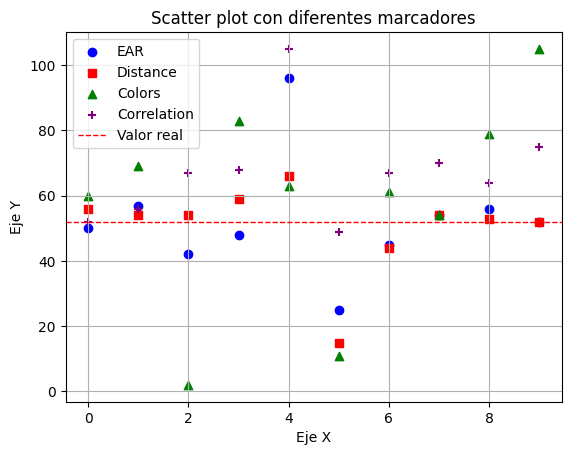

In [29]:
result_per_participant_ear
result_per_participant_dist
result_per_participant_col
result_per_participant_corr


plt.scatter(list(range(10)), result_per_participant_ear['Blink_sample_ear_diff'], marker='o', color='blue', label='EAR')  # círculo
plt.scatter(list(range(10)), result_per_participant_dist['Blink_sample_dist_diff'], marker='s', color='red', label='Distance')   # cuadrado
plt.scatter(list(range(10)), result_per_participant_col['Blink_sample_col_diff'], marker='^', color='green', label='Colors') # triángulo
plt.scatter(list(range(10)), result_per_participant_corr['Blink_sample_corr_diff'], marker='+', color='purple', label='Correlation') # cruz

plt.axhline(y=52, color="red", linestyle="--", lw=1, label= "Valor real")

plt.xlabel('Eje X')
plt.ylabel('Eje Y')
plt.title('Scatter plot con diferentes marcadores')
plt.legend()  # Mostrar la leyenda
plt.grid(True)  # Activar la cuadrícula

# Mostrar
plt.show()


In [ ]:
df_webgazer.groupby('trial')['Blink_sample6_diff'].sum().reset_index()


In [ ]:
#Ahora viene blink byt distance
df_webgazer["Blink_sample"] = df_webgazer["isBlinkByDistance"].apply(lambda x: int(x[0]==True))
df_webgazer["Blink_sample1"] = df_webgazer["isBlinkByDistance"].apply(lambda x: int(x[1]==True))
df_webgazer["Blink_sample2"] = df_webgazer["isBlinkByDistance"].apply(lambda x: int(x[2]==True))
df_webgazer["Blink_sample3"] = df_webgazer["isBlinkByDistance"].apply(lambda x: int(x[3]==True))
df_webgazer["Blink_sample4"] = df_webgazer["isBlinkByDistance"].apply(lambda x: int(x[4]==True))
df_webgazer["Blink_sample5"] = df_webgazer["isBlinkByDistance"].apply(lambda x: int(x[5]==True))

In [ ]:
df_webgazer["Blink_sample0_diff"] = (df_webgazer['Blink_sample'].shift(1)+1 == df_webgazer['Blink_sample'])
df_webgazer["Blink_sample1_diff"] = (df_webgazer['Blink_sample1'].shift(1)+1 == df_webgazer['Blink_sample1'])
df_webgazer["Blink_sample2_diff"] = (df_webgazer['Blink_sample2'].shift(1)+1 == df_webgazer['Blink_sample2'])
df_webgazer["Blink_sample3_diff"] = (df_webgazer['Blink_sample3'].shift(1)+1 == df_webgazer['Blink_sample3'])
df_webgazer["Blink_sample4_diff"] = (df_webgazer['Blink_sample4'].shift(1)+1 == df_webgazer['Blink_sample4'])
df_webgazer["Blink_sample5_diff"] = (df_webgazer['Blink_sample5'].shift(1)+1 == df_webgazer['Blink_sample5'])

results = []
for x in range(6):
    tmp_result = df_webgazer.groupby('trial')['Blink_sample' + str(x) + '_diff'].sum().reset_index()
    #tmp_result['sample'] = x
    results.append(tmp_result)

result = pd.concat(results, axis=1, join='inner')
result

In [5]:
#Ahora viene blink byt colors
df_webgazer["Blink_sample"] = df_webgazer["isBlinkColors"].apply(lambda x: int(x[0]==True))
df_webgazer["Blink_sample1"] = df_webgazer["isBlinkColors"].apply(lambda x: int(x[1]==True))
df_webgazer["Blink_sample2"] = df_webgazer["isBlinkColors"].apply(lambda x: int(x[2]==True))
df_webgazer["Blink_sample3"] = df_webgazer["isBlinkColors"].apply(lambda x: int(x[3]==True))
df_webgazer["Blink_sample4"] = df_webgazer["isBlinkColors"].apply(lambda x: int(x[4]==True))
df_webgazer["Blink_sample5"] = df_webgazer["isBlinkColors"].apply(lambda x: int(x[5]==True))

df_webgazer["Blink_sample0_diff"] = (df_webgazer['Blink_sample'].shift(1)+1 == df_webgazer['Blink_sample'])
df_webgazer["Blink_sample1_diff"] = (df_webgazer['Blink_sample1'].shift(1)+1 == df_webgazer['Blink_sample1'])
df_webgazer["Blink_sample2_diff"] = (df_webgazer['Blink_sample2'].shift(1)+1 == df_webgazer['Blink_sample2'])
df_webgazer["Blink_sample3_diff"] = (df_webgazer['Blink_sample3'].shift(1)+1 == df_webgazer['Blink_sample3'])
df_webgazer["Blink_sample4_diff"] = (df_webgazer['Blink_sample4'].shift(1)+1 == df_webgazer['Blink_sample4'])
df_webgazer["Blink_sample5_diff"] = (df_webgazer['Blink_sample5'].shift(1)+1 == df_webgazer['Blink_sample5'])

results = []
for x in range(6):
    tmp_result = df_webgazer.groupby('trial')['Blink_sample' + str(x) + '_diff'].sum().reset_index()
    #tmp_result['sample'] = x
    results.append(tmp_result)

result = pd.concat(results, axis=1, join='inner')
result

,trial,Blink_sample0_diff,trial,Blink_sample1_diff,trial,Blink_sample2_diff,trial,Blink_sample3_diff,trial,Blink_sample4_diff,trial,Blink_sample5_diff
0,1,108,1,66,1,72,1,58,1,34,1,75
1,2,123,2,87,2,95,2,77,2,46,2,102
2,3,35,3,26,3,28,3,20,3,13,3,31
3,4,155,4,110,4,124,4,93,4,61,4,144
4,5,128,5,89,5,98,5,79,5,50,5,111
5,6,155,6,100,6,108,6,87,6,52,6,124


In [6]:
#Ahora viene blink byt Correlation
df_webgazer["Blink_sample"] = df_webgazer["isBlinkByCorrelation"].apply(lambda x: int(x[0]==True))
df_webgazer["Blink_sample1"] = df_webgazer["isBlinkByCorrelation"].apply(lambda x: int(x[1]==True))
df_webgazer["Blink_sample2"] = df_webgazer["isBlinkByCorrelation"].apply(lambda x: int(x[2]==True))
df_webgazer["Blink_sample3"] = df_webgazer["isBlinkByCorrelation"].apply(lambda x: int(x[3]==True))
df_webgazer["Blink_sample4"] = df_webgazer["isBlinkByCorrelation"].apply(lambda x: int(x[4]==True))
df_webgazer["Blink_sample5"] = df_webgazer["isBlinkByCorrelation"].apply(lambda x: int(x[5]==True))

df_webgazer["Blink_sample0_diff"] = (df_webgazer['Blink_sample'].shift(1)+1 == df_webgazer['Blink_sample'])
df_webgazer["Blink_sample1_diff"] = (df_webgazer['Blink_sample1'].shift(1)+1 == df_webgazer['Blink_sample1'])
df_webgazer["Blink_sample2_diff"] = (df_webgazer['Blink_sample2'].shift(1)+1 == df_webgazer['Blink_sample2'])
df_webgazer["Blink_sample3_diff"] = (df_webgazer['Blink_sample3'].shift(1)+1 == df_webgazer['Blink_sample3'])
df_webgazer["Blink_sample4_diff"] = (df_webgazer['Blink_sample4'].shift(1)+1 == df_webgazer['Blink_sample4'])
df_webgazer["Blink_sample5_diff"] = (df_webgazer['Blink_sample5'].shift(1)+1 == df_webgazer['Blink_sample5'])

results = []
for x in range(6):
    tmp_result = df_webgazer.groupby('trial')['Blink_sample' + str(x) + '_diff'].sum().reset_index()
    #tmp_result['sample'] = x
    results.append(tmp_result)

result = pd.concat(results, axis=1, join='inner')
result

,trial,Blink_sample0_diff,trial,Blink_sample1_diff,trial,Blink_sample2_diff,trial,Blink_sample3_diff,trial,Blink_sample4_diff,trial,Blink_sample5_diff
0,1,90,1,92,1,103,1,81,1,55,1,94
1,2,171,2,99,2,115,2,73,2,39,2,130
2,3,73,3,31,3,44,3,22,3,11,3,53
3,4,133,4,118,4,127,4,97,4,57,4,125
4,5,136,5,100,5,116,5,91,5,54,5,123
5,6,157,6,148,6,162,6,145,6,92,6,148
